In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df = pd.read_csv("C:/Users/hp/Downloads/student performance/StudentPerformance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7.0,99,Yes,9,1,91
1,4.0,82,No,4,2,65
2,8.0,51,Yes,7,2,45
3,5.0,52,Yes,5,2,36
4,7.0,75,No,8,5,66


In [65]:
df.shape

(10000, 6)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9965 non-null   float64
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [67]:
df.isnull().sum()

Hours Studied                       35
Previous Scores                      0
Extracurricular Activities           0
Sleep Hours                          0
Sample Question Papers Practiced     0
Performance Index                    0
dtype: int64

In [68]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'No': 0, 'Yes': 1})

In [69]:
df.describe()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,9965.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.991671,69.445700,0.494800,6.530600,4.583300,55.224800
std,2.589822,17.343152,0.499998,1.695863,2.867348,19.212558
min,1.000000,40.000000,0.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,0.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,1.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000,100.000000


In [70]:
df['Hours Studied'] = df['Hours Studied'].fillna(df['Hours Studied'].mean())

In [71]:
print(df.isnull().sum().sum())

0


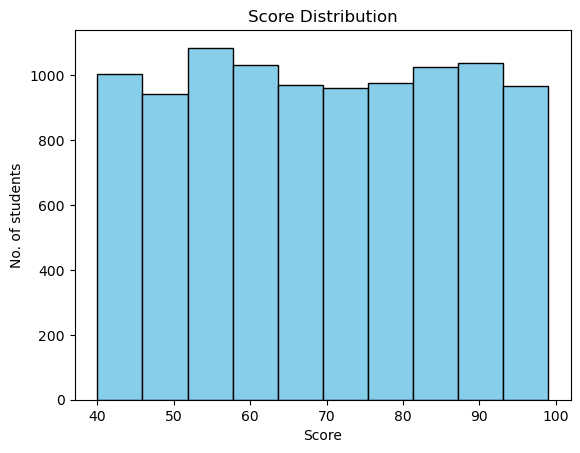

In [72]:
plt.hist(df['Previous Scores'], color='skyblue', edgecolor='black')
plt.title('Score Distribution')
plt.xlabel('Score')
plt.ylabel('No. of students')
plt.show()

In [73]:
df['Extracurricular Activities'].value_counts().reset_index()

,Extracurricular Activities,count
0,0,5052
1,1,4948


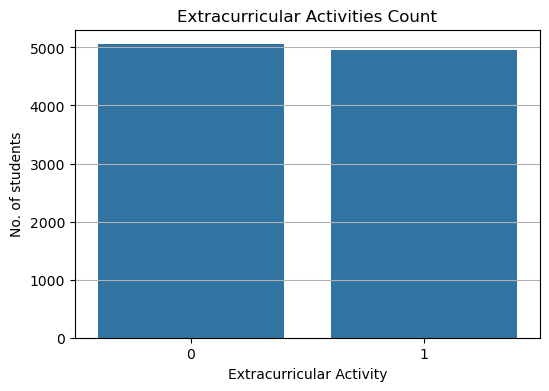

In [74]:
plt.figure(figsize=(6,4))
sns.countplot(x='Extracurricular Activities', data=df)
plt.title('Extracurricular Activities Count')
plt.xlabel('Extracurricular Activity')
plt.ylabel('No. of students')
plt.grid(axis='y')
plt.show()

In [75]:
df['Hours Studied'].value_counts().sort_values(ascending=False)

Hours Studied
1.000000    1151
6.000000    1126
7.000000    1125
3.000000    1113
9.000000    1111
5.000000    1090
4.000000    1085
8.000000    1084
2.000000    1080
4.991671      35
Name: count, dtype: int64

In [76]:
df['Hours Studied'] = np.round(df['Hours Studied'])

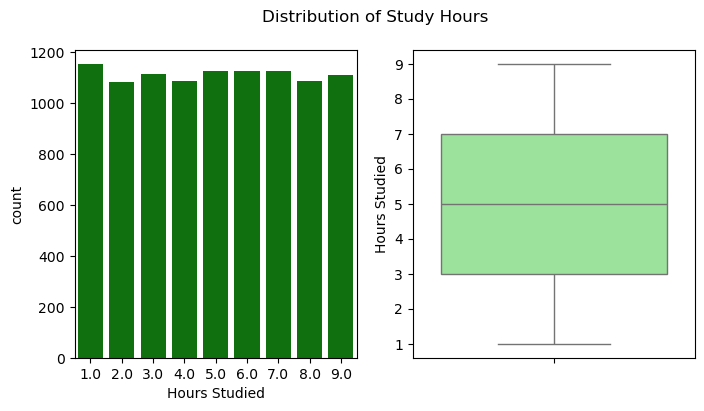

In [77]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.countplot(x='Hours Studied', data=df, color='green')

plt.subplot(1,2,2)
sns.boxplot(df['Hours Studied'], color='lightgreen')

plt.suptitle('Distribution of Study Hours')
plt.show()

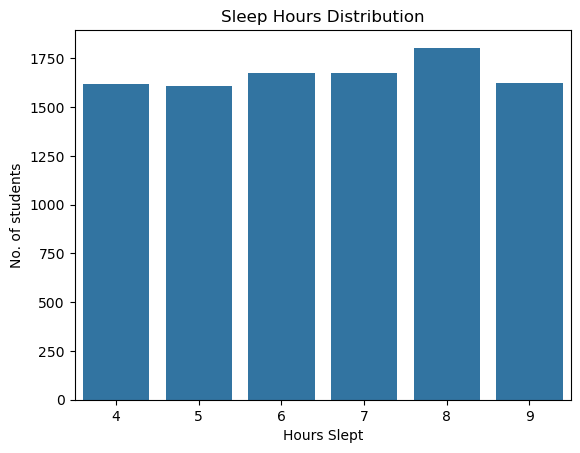

In [78]:
sns.countplot(x='Sleep Hours', data=df)
plt.title('Sleep Hours Distribution')
plt.xlabel('Hours Slept')
plt.ylabel('No. of students')
plt.show()

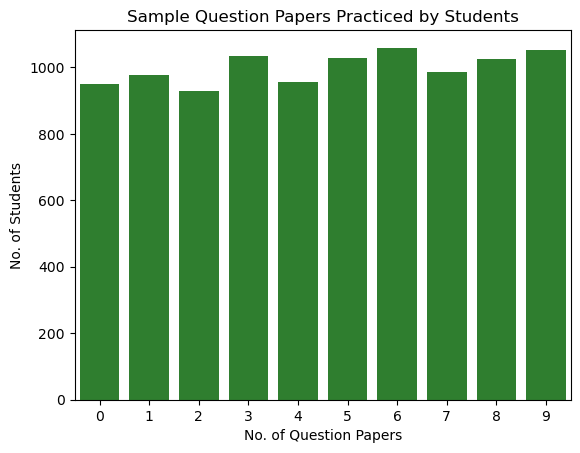

In [79]:
sns.countplot(x='Sample Question Papers Practiced',data=df, color='forestgreen')
plt.title('Sample Question Papers Practiced by Students')
plt.xlabel('No. of Question Papers')
plt.ylabel('No. of Students')
plt.show()

In [80]:
cor_df = df.corr()
cor_df['Performance Index'].sort_values(ascending=False).reset_index()

,index,Performance Index
0,Performance Index,1.000000
1,Previous Scores,0.915189
2,Hours Studied,0.373287
3,Sleep Hours,0.048106
4,Sample Question Papers Practiced,0.043268
5,Extracurricular Activities,0.024525


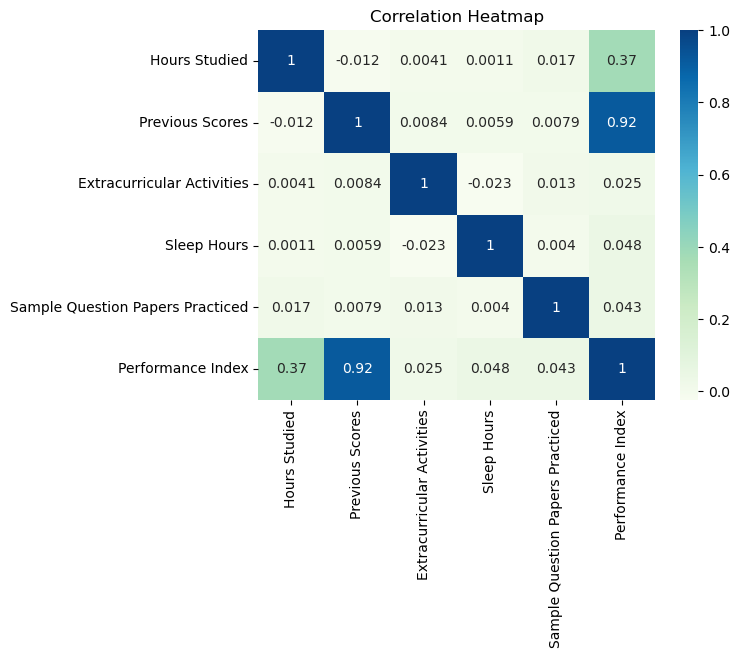

In [81]:
c = df.corr()
sns.heatmap(c, annot=True, cmap='GnBu')
plt.title('Correlation Heatmap')
plt.show()

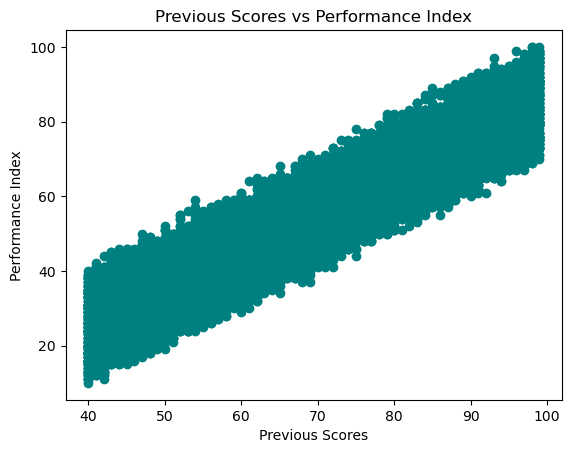

In [82]:
plt.scatter(df['Previous Scores'], df['Performance Index'], color='teal')
plt.title('Previous Scores vs Performance Index')
plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')
plt.show()

### Linear Regression Model

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [84]:
X = df.iloc[:,:-1]
y = df.iloc[:, -1]

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [86]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [87]:
y_pred = lr.predict(X_test)

In [88]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² score:", r2)
print("RMSE:", rmse)

R² score: 0.9884962485929162
RMSE: 2.0647321980415074


In [89]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

coeff_df.reset_index()

,index,Feature,Coefficient
0,0,Hours Studied,2.852659
1,1,Previous Scores,1.016865
2,2,Extracurricular Activities,0.608731
3,3,Sleep Hours,0.477001
4,4,Sample Question Papers Practiced,0.193649


In [90]:
print(lr.intercept_)

-33.91881386290384


### Trial

In [119]:
intercept = lr.intercept_
coeffs = lr.coef_
features = X.columns

equation = f"Performance Index = {intercept:.2f}"

for coef, feature in zip(coeffs, features):
    sign = "+" if coef >= 0 else "-"
    equation += f" {sign} {abs(coef):.2f} × {feature}"

print(equation)

Performance Index = -33.92 + 2.85 × Hours Studied + 1.02 × Previous Scores + 0.61 × Extracurricular Activities + 0.48 × Sleep Hours + 0.19 × Sample Question Papers Practiced


### simulating

In [120]:
baseline = {
    'Hours Studied': df['Hours Studied'].mean(),
    'Previous Scores': df['Previous Scores'].mean(),
    'Extracurricular Activities': df['Extracurricular Activities'].mean(),
    'Sleep Hours': df['Sleep Hours'].mean(),
    'Sample Question Papers Practiced': df['Sample Question Papers Practiced'].mean()
}

In [121]:
def simulate_performance(values):
    prediction = intercept
    for i, feature in enumerate(features):
        prediction += coeffs[i] * values[feature]
    return prediction

In [134]:
simulation_df = pd.DataFrame({
    'Hours Studied': np.arange(2, 9),
    'Sleep Hours': np.linspace(5, 9, 7),
    'Sample Question Papers Practiced': np.arange(0, 14, 2)
})

# Add baseline values for other features
simulation_df['Previous Scores'] = baseline['Previous Scores']
simulation_df['Extracurricular Activities'] = baseline['Extracurricular Activities']

In [135]:
simulation_df['Predicted Performance'] = simulation_df.apply(
    lambda row: simulate_performance(row), axis=1)
simulation_df

,Hours Studied,Sleep Hours,Sample Question Papers Practiced,Previous Scores,Extracurricular Activities,Predicted Performance
0,2,5.000000,0,69.4457,0.4948,45.089614
1,3,5.666667,2,69.4457,0.4948,48.647572
2,4,6.333333,4,69.4457,0.4948,52.205530
3,5,7.000000,6,69.4457,0.4948,55.763488
4,6,7.666667,8,69.4457,0.4948,59.321446
5,7,8.333333,10,69.4457,0.4948,62.879404
6,8,9.000000,12,69.4457,0.4948,66.437362


In [137]:
baseline_perf = simulate_performance(baseline)
simulation_df['Impact'] = simulation_df['Predicted Performance'] - baseline_perf

In [138]:
simulation_df

,Hours Studied,Sleep Hours,Sample Question Papers Practiced,Previous Scores,Extracurricular Activities,Predicted Performance,Impact
0,2,5.000000,0,69.4457,0.4948,45.089614,-10.151949
1,3,5.666667,2,69.4457,0.4948,48.647572,-6.593991
2,4,6.333333,4,69.4457,0.4948,52.205530,-3.036034
3,5,7.000000,6,69.4457,0.4948,55.763488,0.521924
4,6,7.666667,8,69.4457,0.4948,59.321446,4.079882
5,7,8.333333,10,69.4457,0.4948,62.879404,7.637840
6,8,9.000000,12,69.4457,0.4948,66.437362,11.195798


In [91]:
intercept = lr.intercept_
coefficients = lr.coef_
features = X.columns

def predict_performance(row):
    return intercept + sum(coefficients[i] * row[features[i]]
                            for i in range(len(features)))

In [92]:
predict_performance(df.iloc[0])

np.float64(91.8148259658168)

In [96]:
def what_if(feature, delta):
    idx = list(features).index(feature)
    return coefficients[idx] * delta

In [97]:
what_if('Hours Studied', 2)

np.float64(5.705317028097387)

In [93]:
def what_if_analysis(base, changes):
    delta = 0
    for feature, change in changes.items():
        delta += base[feature] * change
    return delta

In [110]:
hours = np.arange(0, 10)

performance1 = (
    lr.intercept_
    + lr.coef_[0] * hours
    + lr.coef_[1] * df['Previous Scores'].mean()
    + lr.coef_[2] * df['Extracurricular Activities'].mean()
    + lr.coef_[3] * df['Sleep Hours'].mean()
    + lr.coef_[4] * df['Sample Question Papers Practiced'].mean()
)

In [111]:
sample = np.arange(0, 10)

performance2 = (
    lr.intercept_
    + lr.coef_[0] * df['Hours Studied'].mean()
    + lr.coef_[1] * df['Previous Scores'].mean()
    + lr.coef_[2] * df['Extracurricular Activities'].mean()
    + lr.coef_[3] * df['Sleep Hours'].mean()
    + lr.coef_[4] * sample
)

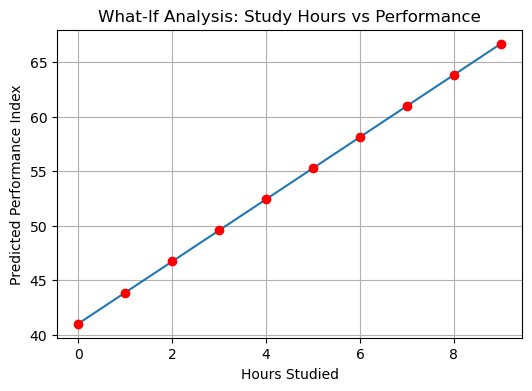

In [113]:
plt.figure(figsize=(6,4))
plt.plot(hours, performance1, marker='o', mfc='red', mec='red')
plt.xlabel('Hours Studied')
plt.ylabel('Predicted Performance Index')
plt.title('What-If Analysis: Study Hours vs Performance')
plt.grid()
plt.show()

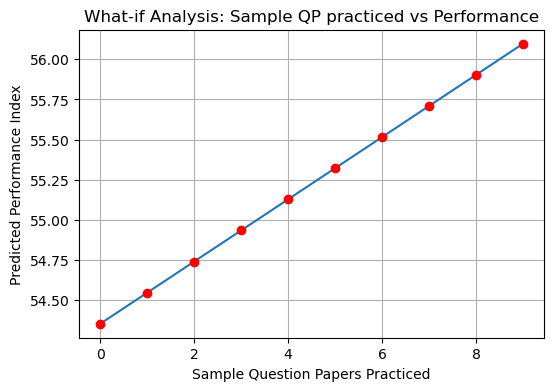

In [114]:
plt.figure(figsize=(6,4))
plt.plot(sample, performance, marker='o', mfc='red', mec='red')
plt.title('What-if Analysis: Sample QP practiced vs Performance')
plt.xlabel('Sample Question Papers Practiced')
plt.ylabel('Predicted Performance Index')
plt.grid()
plt.show()

### Logistic Regression

In [39]:
df['Pass'] = (df['Performance Index'] >= 50).astype(int)
df[['Performance Index', 'Pass']].head()

,Performance Index,Pass
0,91,1
1,65,1
2,45,0
3,36,0
4,66,1


In [40]:
X = df.drop(['Performance Index', 'Pass'], axis=1)
y = df['Pass']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [46]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.976

Confusion Matrix:
 [[ 788   30]
 [  18 1164]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       818
           1       0.97      0.98      0.98      1182

    accuracy                           0.98      2000
   macro avg       0.98      0.97      0.98      2000
weighted avg       0.98      0.98      0.98      2000



<Figure size 400x400 with 0 Axes>

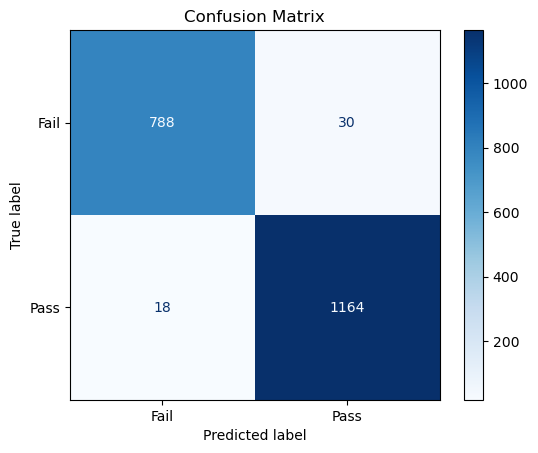

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(4,4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail','Pass'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [55]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df

,Feature,Coefficient
1,Previous Scores,11.717889
0,Hours Studied,4.736306
3,Sleep Hours,0.517577
4,Sample Question Papers Practiced,0.256992
2,Extracurricular Activities,0.173441
